# SAC - Lunar Lander

In [1]:
%pip install gymnasium
%pip install "gymnasium[box2d]"
%pip install swig

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import gymnasium as gym
from train import train_sac
from agent import SACAgent
from buffer import PrioritizedReplayBuffer
from train import train_sac, OUNoise
import matplotlib.pyplot as plt
import numpy as np

In [3]:
env = gym.make("LunarLanderContinuous-v3", render_mode=None)
agent = SACAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.shape[0], hidden_dim=256, env=env, alpha_lr=3e-4, actor_lr=3e-4, critic_lr=3e-4)
replay_buffer = PrioritizedReplayBuffer(capacity=2_00_000, seed=0, alpha=0.6, eps=1e-5)
noise = OUNoise(action_dim=env.action_space.shape[0])

In [4]:
# POTENTIAL_SCALE = 10.0

# def mountain_car_potential(state):
#     position, velocity = state[0], state[1]
#     # kinematic_energy = 1/2 * mv^2
#     # = 1/2 * 1 * v^2 = 0.5 * v^2
#     kinematic_energy = 0.5 * velocity**2
#     # Potential_energy = mgh
#     # m = 1, g = 0.0025
#     # PE directly proportional to h
#     # h = sin(3x)
#     potential_energy = np.sin(3*position)
#     return POTENTIAL_SCALE + kinematic_energy + potential_energy

In [5]:
episode_rewards, critic1_loss, critic2_loss, actor_loss, alpha_loss, alpha, best_state_dict = train_sac(env=env, agent=agent, replay_buffer=replay_buffer, total_steps=300_000, batch_size=512, gamma=0.99, warmup_steps=10000, potential_fn=None, exploration_noise=noise) 

  2%|▏         | 5632/300000 [00:00<00:10, 28508.88it/s]

Episode = 1, Reward = -794.6, Avg10 = -794.6, Best Reward=-794.6
Episode = 2, Reward = -1003.1, Avg10 = -898.9, Best Reward=-794.6
Episode = 3, Reward = -788.8, Avg10 = -862.2, Best Reward=-788.8
Episode = 4, Reward = -654.6, Avg10 = -810.3, Best Reward=-654.6
Episode = 5, Reward = -1351.8, Avg10 = -918.6, Best Reward=-654.6
Episode = 6, Reward = -822.8, Avg10 = -902.6, Best Reward=-654.6
Episode = 7, Reward = -853.8, Avg10 = -895.6, Best Reward=-654.6
Episode = 8, Reward = -1113.4, Avg10 = -922.9, Best Reward=-654.6
Episode = 9, Reward = -728.6, Avg10 = -901.3, Best Reward=-654.6
Episode = 10, Reward = -1304.2, Avg10 = -941.6, Best Reward=-654.6
Episode = 11, Reward = -811.9, Avg10 = -943.3, Best Reward=-654.6
Episode = 12, Reward = -792.3, Avg10 = -922.2, Best Reward=-654.6
Episode = 13, Reward = -677.0, Avg10 = -911.0, Best Reward=-654.6
Episode = 14, Reward = -1188.1, Avg10 = -964.4, Best Reward=-654.6
Episode = 15, Reward = -1188.4, Avg10 = -948.1, Best Reward=-654.6
Episode = 16,

  3%|▎         | 8586/300000 [00:00<00:10, 28977.78it/s]/media/jayden/KINGSTON/RL/SAC/buffer.py:86: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.FloatTensor(actions),


Episode = 59, Reward = -523.5, Avg10 = -838.7, Best Reward=-523.5
Episode = 60, Reward = -688.7, Avg10 = -831.2, Best Reward=-523.5
Episode = 61, Reward = -1241.4, Avg10 = -881.2, Best Reward=-523.5
Episode = 62, Reward = -782.7, Avg10 = -880.2, Best Reward=-523.5
Episode = 63, Reward = -1519.4, Avg10 = -960.4, Best Reward=-523.5
Episode = 64, Reward = -741.5, Avg10 = -961.8, Best Reward=-523.5
Episode = 65, Reward = -677.4, Avg10 = -904.8, Best Reward=-523.5
Episode = 66, Reward = -622.3, Avg10 = -876.4, Best Reward=-523.5
Episode = 67, Reward = -787.9, Avg10 = -829.0, Best Reward=-523.5
Episode = 68, Reward = -840.4, Avg10 = -842.5, Best Reward=-523.5
Episode = 69, Reward = -638.3, Avg10 = -854.0, Best Reward=-523.5
Episode = 70, Reward = -769.3, Avg10 = -862.1, Best Reward=-523.5
Episode = 71, Reward = -626.0, Avg10 = -800.5, Best Reward=-523.5
Episode = 72, Reward = -730.6, Avg10 = -795.3, Best Reward=-523.5
Episode = 73, Reward = -628.7, Avg10 = -706.2, Best Reward=-523.5
Episode 

  4%|▎         | 10521/300000 [00:20<15:26, 312.61it/s] 

...

100%|█████████▉| 299597/300000 [3:41:29<00:18, 22.22it/s]

Episode = 943, Reward = 260.7, Avg10 = 272.6, Best Reward=310.4


100%|█████████▉| 299843/300000 [3:41:40<00:06, 22.67it/s]

Episode = 944, Reward = 271.4, Avg10 = 273.1, Best Reward=310.4


100%|██████████| 300000/300000 [3:41:47<00:00, 22.54it/s]


Text(0, 0.5, 'Rewards')

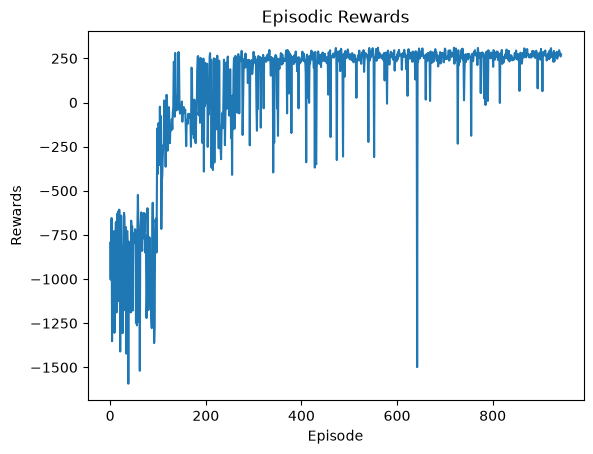

In [6]:
plt.plot(range(len(episode_rewards)), episode_rewards)
plt.title("Episodic Rewards")
plt.xlabel("Episode")
plt.ylabel("Rewards")

In [12]:
np.max(episode_rewards)

np.float64(310.3800990291629)

In [13]:
np.argmax(episode_rewards)

np.int64(560)

Text(0, 0.5, 'Critic 1 Loss')

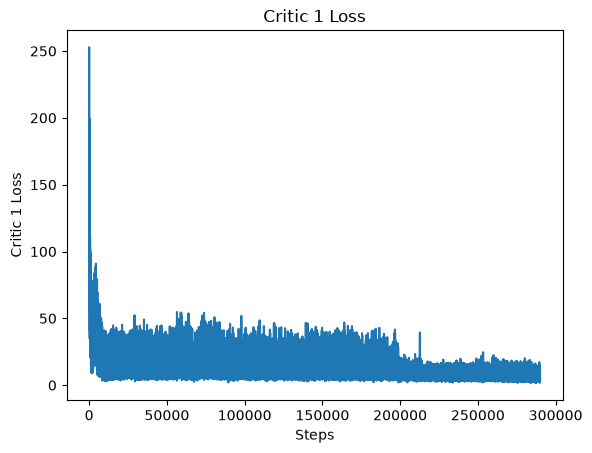

In [7]:
plt.plot(range(len(critic1_loss)), critic1_loss)
plt.title("Critic 1 Loss")
plt.xlabel("Steps")
plt.ylabel("Critic 1 Loss")

Text(0, 0.5, 'Critic 2 Loss')

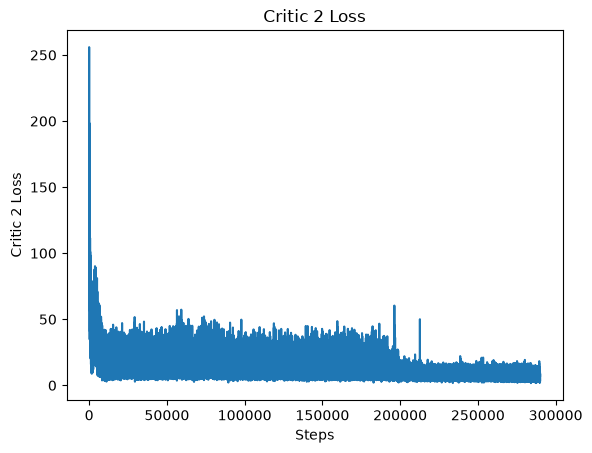

In [8]:
plt.plot(range(len(critic2_loss)), critic2_loss)
plt.title("Critic 2 Loss")
plt.xlabel("Steps")
plt.ylabel("Critic 2 Loss")

Text(0, 0.5, 'Actor Loss')

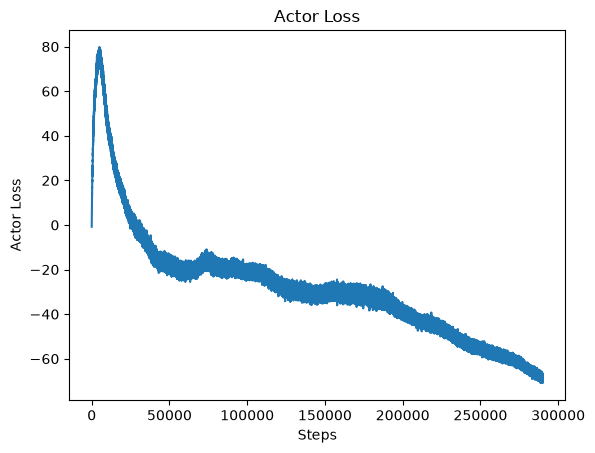

In [9]:
plt.plot(range(len(actor_loss)), actor_loss)
plt.title("Actor Loss")
plt.xlabel("Steps")
plt.ylabel("Actor Loss")

Text(0, 0.5, 'Alpha Loss')

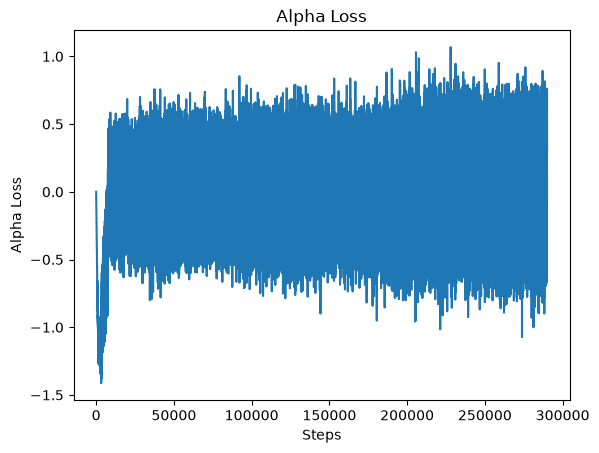

In [10]:
plt.plot(range(len(alpha_loss)), alpha_loss)
plt.title("Alpha Loss")
plt.xlabel("Steps")
plt.ylabel("Alpha Loss")

Text(0, 0.5, 'Alpha')

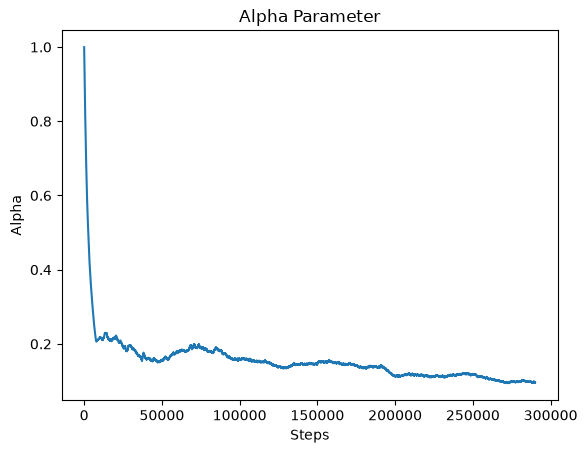

In [11]:
alpha_vals = [a.detach().cpu().item() for a in alpha]
plt.plot(range(len(alpha_vals)), alpha_vals)
plt.title("Alpha Parameter")
plt.xlabel("Steps")
plt.ylabel("Alpha")